In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
import pickle


## Load data

In [13]:

results_path = "../../Data/VarPoisson/varpoisson_N16_epochs180_seeds3_20260504_163028.pkl"
#results_path = "Data/VarPoisson/varpoisson_N16_epochs180_seeds3_20260504_163028.pkl"

if not os.path.exists(results_path):
    raise FileNotFoundError(f"Could not find results file: {results_path}")

with open(results_path, "rb") as f:
    payload = pickle.load(f)

# Restore variables expected by the plotting scripts
all_results = payload["all_results"]
aggregated = payload["aggregated"]
all_model_keys = payload["all_model_keys"]

N = payload["N"]
n_epochs = payload["n_epochs"]
richer_epsilon_list = payload["richer_epsilon_list"]

# Optional metadata restore
equation_type = payload.get("equation_type")
model_kind = payload.get("model_kind")
noise_std = payload.get("noise_std")
seed_list = payload.get("seed_list")

print("Loaded results from:", results_path)
print("Equation:", equation_type)
print("Models:", all_model_keys)
print("N:", N)
print("n_epochs:", n_epochs)
print("richer_epsilon_list:", richer_epsilon_list)

Loaded results from: ../../Data/VarPoisson/varpoisson_N16_epochs180_seeds3_20260504_163028.pkl
Equation: varpoisson
Models: ['spectral_filter_baseline', 'diag_phase_free', 'unitary', 'richer_spectral_eps_0.00', 'richer_spectral_eps_0.25', 'richer_spectral_eps_0.50', 'richer_spectral_eps_1.00', 'hhl_like_structured', 'hhl_like_free', 'hwe']
N: 16
n_epochs: 180
richer_epsilon_list: [0.0, 0.25, 0.5, 1.0]


## Absolute error

/tmp/ipykernel_2479156/3719145199.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Purples", len(richer_keys) + 3)


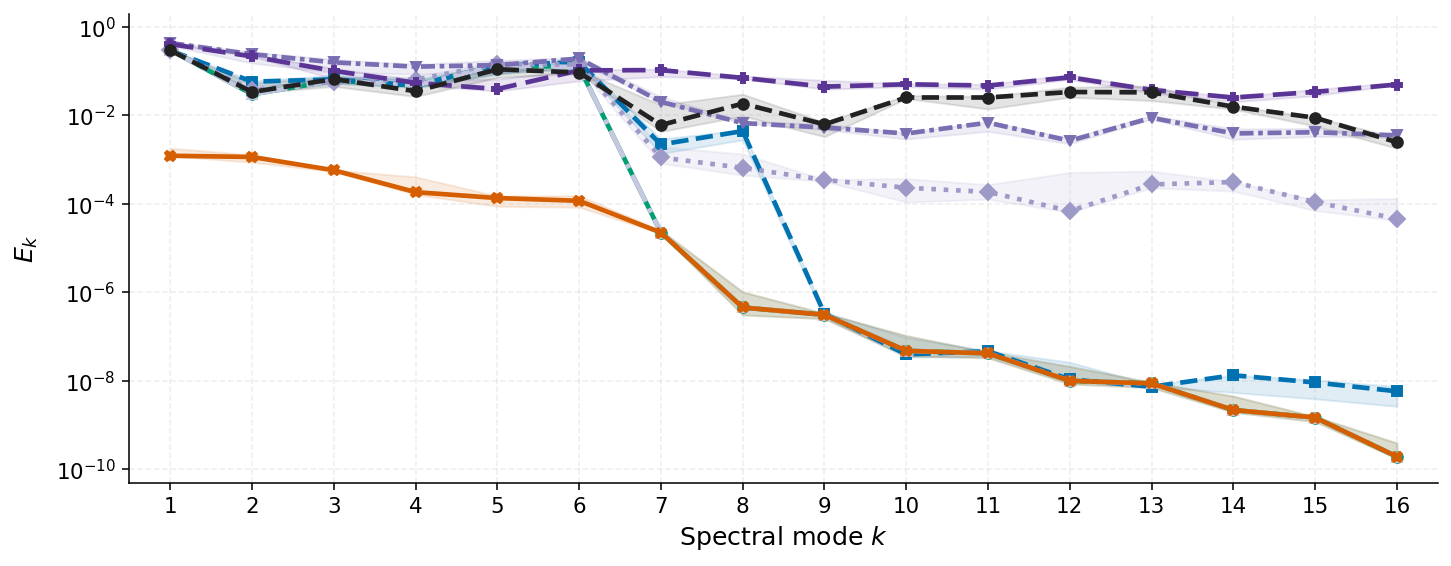

In [14]:
save_figures = True
fig_dir = "paper_figures"
os.makedirs(fig_dir, exist_ok=True)

eps_log = 1e-40

exclude_models = {"spectral_filter_baseline", "hhl_like_structured"}
plot_model_keys = [mk for mk in all_model_keys if mk not in exclude_models]

label_map = {
    "diag_phase_free": "Diagonal phase",
    "unitary": "Spectral hardware-efficient",
    "hhl_like_free": "HHL-inspired",
    "hwe": "Hardware-efficient baseline",
}

for eps in richer_epsilon_list:
    label_map[f"richer_spectral_eps_{eps:.2f}"] = rf"Richer spectral $\epsilon={eps:.2f}$"

color_map = {
    "diag_phase_free": "#009E73",
    "unitary": "#0072B2",
    "hhl_like_free": "#D55E00",
    "hwe": "#222222",
}

richer_keys = [
    f"richer_spectral_eps_{eps:.2f}"
    for eps in richer_epsilon_list
    if f"richer_spectral_eps_{eps:.2f}" in plot_model_keys
]

cmap = cm.get_cmap("Purples", len(richer_keys) + 3)
for i, mk in enumerate(richer_keys):
    color_map[mk] = cmap(i + 2)

line_styles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1)), (0, (5, 2))]
markers = ["o", "s", "^", "D", "v", "P", "X"]

style_map = {
    mk: {
        "linestyle": line_styles[i % len(line_styles)],
        "marker": markers[i % len(markers)],
    }
    for i, mk in enumerate(plot_model_keys)
}

plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "lines.linewidth": 2.4,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "grid.linestyle": "--",
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def abs_error_log_stats(model_key):
    arr = np.stack([res[model_key]["abs_err"] for res in all_results], axis=0)
    log_arr = np.log10(arr + eps_log)

    med = np.median(log_arr, axis=0)
    q25 = np.percentile(log_arr, 25, axis=0)
    q75 = np.percentile(log_arr, 75, axis=0)

    return med, q25, q75


k_plot = np.arange(1, N + 1)

fig, ax = plt.subplots(figsize=(10.5, 4.8))

all_log_values = []

for mk in plot_model_keys:
    med, q25, q75 = abs_error_log_stats(mk)

    all_log_values.extend(q25)
    all_log_values.extend(q75)

    ax.plot(
        k_plot,
        med,
        label=label_map.get(mk, mk),
        color=color_map.get(mk),
        linestyle=style_map[mk]["linestyle"],
        marker=style_map[mk]["marker"],
        markersize=5.5,
    )

    ax.fill_between(
        k_plot,
        q25,
        q75,
        color=color_map.get(mk),
        alpha=0.12,
    )

# ============================================================
# X axis
# ============================================================

ax.set_xlim(0.5, N + 0.5)
ax.set_xticks(np.arange(1, N + 1, 1))
ax.set_xlabel(r"Spectral mode $k$")

# ============================================================
# Y axis: dynamic with max 8 labels
# ============================================================

all_log_values = np.array(all_log_values)

ymin = np.floor(np.nanmin(all_log_values))
ymax = np.ceil(np.nanmax(all_log_values))

# Clamp practical limits
ymin = max(ymin, -40)
ymax = min(ymax, 2)

n_labels_max = 8
span = ymax - ymin
step = max(1, int(np.ceil(span / (n_labels_max - 1))))

# Prefer clean even steps when possible
if step > 1 and step % 2 != 0:
    step += 1

tick_vals = np.arange(ymax, ymin - 1, -step)

ax.set_ylim(ymin - 0.3, ymax + 0.3)
ax.set_yticks(tick_vals)
ax.set_yticklabels([rf"$10^{{{int(v)}}}$" for v in tick_vals])

ax.set_ylabel(
    r"$E_k$",
    #r"$E_k=\mathrm{median}\!\left(|\hat{u}_{\theta,k}-\hat{u}_k|^2\right)$",
    labelpad=8,
)

# ============================================================
# Legend
# ============================================================

# ax.legend(
#     frameon=False,
#     ncol=4,
#     loc="upper center",
#     bbox_to_anchor=(0.5, -0.18),
# )

fig.tight_layout(rect=[0, 0.13, 1, 1])

if save_figures:
    fig.savefig(
        os.path.join(fig_dir, "fig_absolute_spectral_error_paper_3.pdf"),
        bbox_inches="tight",
    )
    fig.savefig(
        os.path.join(fig_dir, "fig_absolute_spectral_error_paper.png"),
        bbox_inches="tight",
    )

plt.show()

## Loss

/tmp/ipykernel_2479156/2128568970.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Purples", len(richer_keys) + 3)


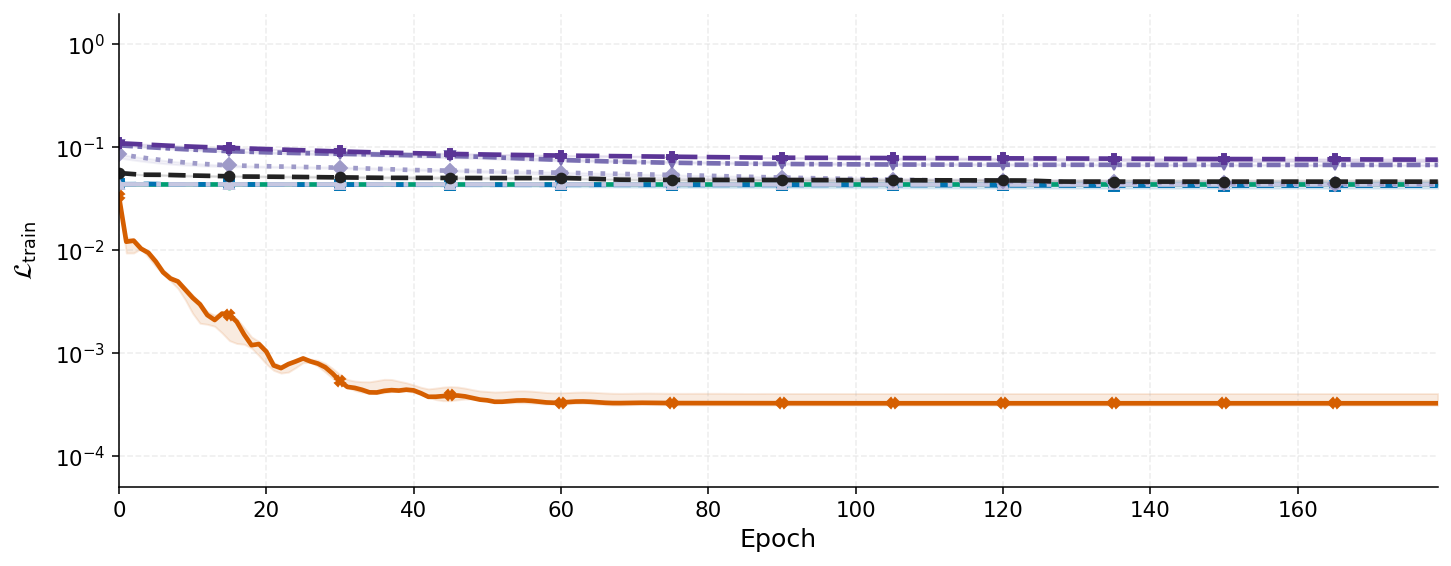

In [15]:
save_figures = True
fig_dir = "paper_figures"
os.makedirs(fig_dir, exist_ok=True)

eps_log = 1e-40

exclude_models = {"spectral_filter_baseline", "hhl_like_structured"}
plot_model_keys = [mk for mk in all_model_keys if mk not in exclude_models]

label_map = {
    "diag_phase_free": "Diagonal phase",
    "unitary": "Spectral hardware-efficient",
    "hhl_like_free": "HHL-inspired Model",
    "hwe": "Hardware-efficient baseline",
}

for eps in richer_epsilon_list:
    label_map[f"richer_spectral_eps_{eps:.2f}"] = rf"Richer spectral $\epsilon={eps:.2f}$"

color_map = {
    "diag_phase_free": "#009E73",
    "unitary": "#0072B2",
    "hhl_like_free": "#D55E00",
    "hwe": "#222222",
}

richer_keys = [
    f"richer_spectral_eps_{eps:.2f}"
    for eps in richer_epsilon_list
    if f"richer_spectral_eps_{eps:.2f}" in plot_model_keys
]

cmap = cm.get_cmap("Purples", len(richer_keys) + 3)
for i, mk in enumerate(richer_keys):
    color_map[mk] = cmap(i + 2)

line_styles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1)), (0, (5, 2))]
markers = ["o", "s", "^", "D", "v", "P", "X"]

style_map = {
    mk: {
        "linestyle": line_styles[i % len(line_styles)],
        "marker": markers[i % len(markers)],
    }
    for i, mk in enumerate(plot_model_keys)
}

plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "lines.linewidth": 2.4,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "grid.linestyle": "--",
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def train_loss_log_stats(model_key):
    arr = np.stack([res[model_key]["train_loss"] for res in all_results], axis=0)
    log_arr = np.log10(arr + eps_log)

    med = np.median(log_arr, axis=0)
    q25 = np.percentile(log_arr, 25, axis=0)
    q75 = np.percentile(log_arr, 75, axis=0)

    return med, q25, q75


epochs = np.arange(n_epochs)

fig, ax = plt.subplots(figsize=(10.5, 4.8))

all_log_values = []

for mk in plot_model_keys:
    med, q25, q75 = train_loss_log_stats(mk)

    all_log_values.extend(q25)
    all_log_values.extend(q75)

    ax.plot(
        epochs,
        med,
        label=label_map.get(mk, mk),
        color=color_map.get(mk),
        linestyle=style_map[mk]["linestyle"],
        marker=style_map[mk]["marker"],
        markersize=5.0,
        markevery=max(1, n_epochs // 12),
    )

    ax.fill_between(
        epochs,
        q25,
        q75,
        color=color_map.get(mk),
        alpha=0.12,
    )

# ============================================================
# X axis
# ============================================================

ax.set_xlim(0, n_epochs - 1)
ax.set_xlabel("Epoch")

# ============================================================
# Y axis: dynamic with max 8 labels
# ============================================================

all_log_values = np.array(all_log_values)

ymin = np.floor(np.nanmin(all_log_values))
ymax = np.ceil(np.nanmax(all_log_values))

ymin = max(ymin, -40)
ymax = min(ymax, 2)

n_labels_max = 8
span = ymax - ymin
step = max(1, int(np.ceil(span / (n_labels_max - 1))))

if step > 1 and step % 2 != 0:
    step += 1

tick_vals = np.arange(ymax, ymin - 1, -step)

ax.set_ylim(ymin - 0.3, ymax + 0.3)
ax.set_yticks(tick_vals)
ax.set_yticklabels([rf"$10^{{{int(v)}}}$" for v in tick_vals])

ax.set_ylabel(
    #r"$\mathcal{L}_{\mathrm{train}}=\mathrm{median}\!\left(\frac{1}{N}\|u_\theta-u\|_2^2\right)$",
    r"$\mathcal{L}_{\mathrm{train}}$",
    labelpad=8,
)

# ============================================================
# Legend
# ============================================================

# ax.legend(
#     frameon=False,
#     ncol=4,
#     loc="upper center",
#     bbox_to_anchor=(0.5, -0.18),
# )

fig.tight_layout(rect=[0, 0.13, 1, 1])

if save_figures:
    fig.savefig(
        os.path.join(fig_dir, "fig_training_loss_paper_3.pdf"),
        bbox_inches="tight",
    )
    fig.savefig(
        os.path.join(fig_dir, "fig_training_loss_paper_3.png"),
        bbox_inches="tight",
    )

plt.show()

## Spectral derivative sensitivity

/tmp/ipykernel_2479156/3891840791.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Purples", len(richer_keys) + 3)


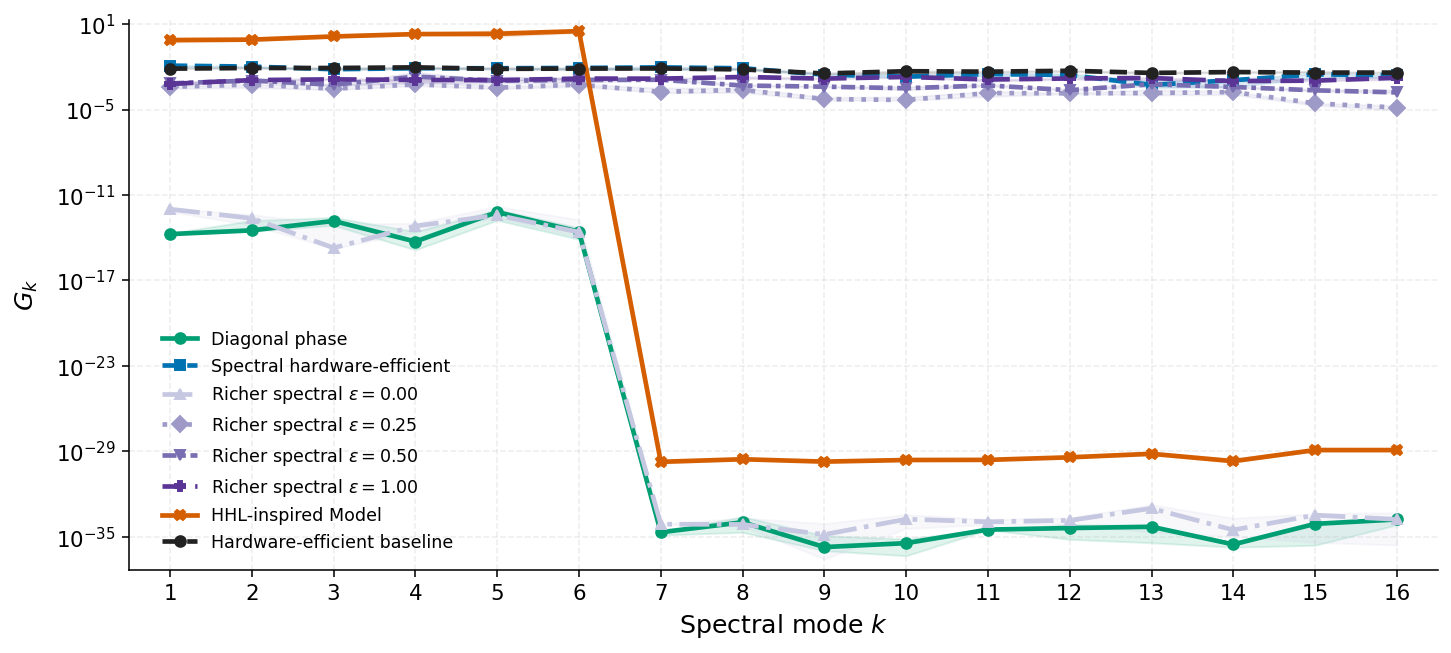

In [16]:
save_figures = True
fig_dir = "paper_figures"
os.makedirs(fig_dir, exist_ok=True)

eps_log = 1e-40

exclude_models = {"spectral_filter_baseline", "hhl_like_structured"}
plot_model_keys = [mk for mk in all_model_keys if mk not in exclude_models]

label_map = {
    "diag_phase_free": "Diagonal phase",
    "unitary": "Spectral hardware-efficient",
    "hhl_like_free": "HHL-inspired Model",
    "hwe": "Hardware-efficient baseline",
}

for eps in richer_epsilon_list:
    label_map[f"richer_spectral_eps_{eps:.2f}"] = rf"Richer spectral $\epsilon={eps:.2f}$"

color_map = {
    "diag_phase_free": "#009E73",
    "unitary": "#0072B2",
    "hhl_like_free": "#D55E00",
    "hwe": "#222222",
}

richer_keys = [
    f"richer_spectral_eps_{eps:.2f}"
    for eps in richer_epsilon_list
    if f"richer_spectral_eps_{eps:.2f}" in plot_model_keys
]

cmap = cm.get_cmap("Purples", len(richer_keys) + 3)
for i, mk in enumerate(richer_keys):
    color_map[mk] = cmap(i + 2)

line_styles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1)), (0, (5, 2))]
markers = ["o", "s", "^", "D", "v", "P", "X"]

style_map = {
    mk: {
        "linestyle": line_styles[i % len(line_styles)],
        "marker": markers[i % len(markers)],
    }
    for i, mk in enumerate(plot_model_keys)
}

plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "legend.fontsize": 9,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "lines.linewidth": 2.4,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "grid.linestyle": "--",
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def grad_power_log_stats(model_key):
    arr = np.stack([res[model_key]["grad_power"] for res in all_results], axis=0)
    log_arr = np.log10(arr + eps_log)

    med = np.median(log_arr, axis=0)
    q25 = np.percentile(log_arr, 25, axis=0)
    q75 = np.percentile(log_arr, 75, axis=0)

    return med, q25, q75


k_plot = np.arange(1, N + 1)

fig, ax = plt.subplots(figsize=(10.5, 4.8))

all_log_values = []

for mk in plot_model_keys:
    med, q25, q75 = grad_power_log_stats(mk)

    all_log_values.extend(q25)
    all_log_values.extend(q75)

    ax.plot(
        k_plot,
        med,
        label=label_map.get(mk, mk),
        color=color_map.get(mk),
        linestyle=style_map[mk]["linestyle"],
        marker=style_map[mk]["marker"],
        markersize=5.5,
    )

    ax.fill_between(
        k_plot,
        q25,
        q75,
        color=color_map.get(mk),
        alpha=0.12,
    )

# X axis
ax.set_xlim(0.5, N + 0.5)
ax.set_xticks(np.arange(1, N + 1, 1))
ax.set_xlabel(r"Spectral mode $k$")

# Y axis: powers of ten, max 8 labels
all_log_values = np.array(all_log_values)

ymin = np.floor(np.nanmin(all_log_values))
ymax = np.ceil(np.nanmax(all_log_values))

ymin = max(ymin, -40)
ymax = min(ymax, 2)

n_labels_max = 8
span = ymax - ymin
step = max(1, int(np.ceil(span / (n_labels_max - 1))))

if step > 1 and step % 2 != 0:
    step += 1

tick_vals = np.arange(ymax, ymin - 1, -step)

ax.set_ylim(ymin - 0.3, ymax + 0.3)
ax.set_yticks(tick_vals)
ax.set_yticklabels([rf"$10^{{{int(v)}}}$" for v in tick_vals])

ax.set_ylabel(
    #r"$G_k=\mathrm{median}\!\left(\frac{1}{P}\sum_{p=1}^{P}\left|\partial_{\theta_p}\hat{u}_{\theta,k}\right|^2\right)$",
    r"$G_k$",

    labelpad=8,
)

# Legend inside bottom-left corner
ax.legend(
    frameon=False,
    ncol=1,
    loc="lower left",
    bbox_to_anchor=(0.02, 0.02),
    borderaxespad=0.0,
)

fig.tight_layout()

if save_figures:
    fig.savefig(
        os.path.join(fig_dir, "fig_gradient_power_paper.pdf"),
        bbox_inches="tight",
    )
    fig.savefig(
        os.path.join(fig_dir, "fig_gradient_power_paper.png"),
        bbox_inches="tight",
    )

plt.show()

## Variance

/tmp/ipykernel_2479156/2768728149.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Purples", len(richer_keys) + 3)


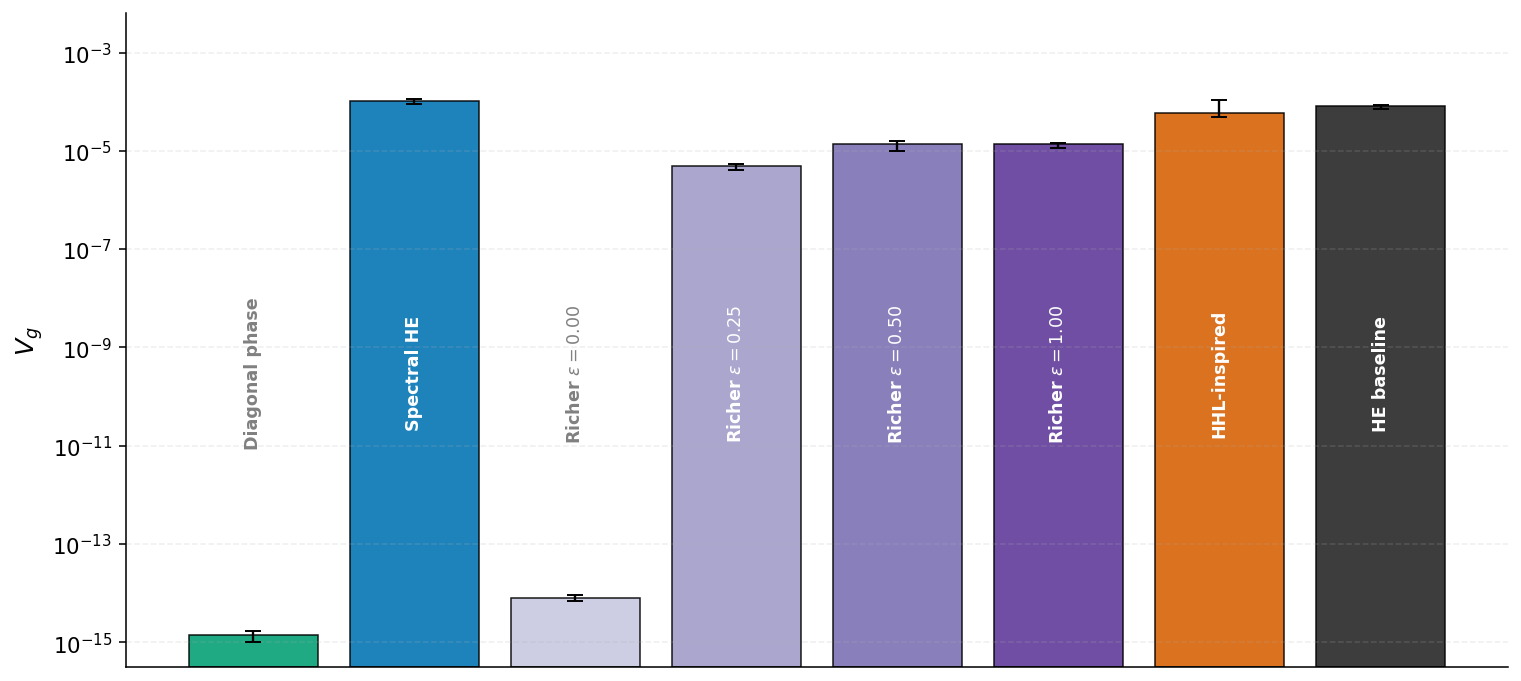

In [17]:
save_figures = True
fig_dir = "paper_figures"
os.makedirs(fig_dir, exist_ok=True)

eps_log = 1e-40

exclude_models = {"spectral_filter_baseline", "hhl_like_structured"}
plot_model_keys = [mk for mk in all_model_keys if mk not in exclude_models]

label_map = {
    "diag_phase_free": "Diagonal phase",
    "unitary": "Spectral HE",
    "hhl_like_free": "HHL-inspired",
    "hwe": "HE baseline",
}

for eps in richer_epsilon_list:
    label_map[f"richer_spectral_eps_{eps:.2f}"] = rf"Richer $\epsilon={eps:.2f}$"

color_map = {
    "diag_phase_free": "#009E73",
    "unitary": "#0072B2",
    "hhl_like_free": "#D55E00",
    "hwe": "#222222",
}

richer_keys = [
    f"richer_spectral_eps_{eps:.2f}"
    for eps in richer_epsilon_list
    if f"richer_spectral_eps_{eps:.2f}" in plot_model_keys
]

cmap = cm.get_cmap("Purples", len(richer_keys) + 3)
for i, mk in enumerate(richer_keys):
    color_map[mk] = cmap(i + 2)

plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 13,
    "ytick.labelsize": 11,
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "axes.grid": True,
    "grid.alpha": 0.20,
    "grid.linestyle": "--",
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def grad_variance_stats(model_key):
    arr = np.array(
        [res[model_key]["grad_var_mean"] for res in all_results],
        dtype=float
    )

    log_arr = np.log10(arr + eps_log)

    med = np.median(log_arr)
    q25 = np.percentile(log_arr, 25)
    q75 = np.percentile(log_arr, 75)

    return med, q25, q75


# ============================================================
# Collect values
# ============================================================

vals, q25s, q75s, cols = [], [], [], []

for mk in plot_model_keys:
    med, q25, q75 = grad_variance_stats(mk)

    vals.append(med)
    q25s.append(q25)
    q75s.append(q75)
    cols.append(color_map.get(mk))

vals = np.array(vals)
q25s = np.array(q25s)
q75s = np.array(q75s)

# ============================================================
# Axis limits
# ============================================================

ymin = np.floor(np.min(q25s))
ymax = np.ceil(np.max(q75s))

base = ymin - 0.5
heights = vals - base

x = np.arange(len(plot_model_keys))

# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(figsize=(11, 5.0))

bars = ax.bar(
    x,
    heights,
    bottom=base,
    color=cols,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.88,
)

# Error bars
yerr = np.vstack([vals - q25s, q75s - vals])

ax.errorbar(
    x,
    vals,
    yerr=yerr,
    fmt="none",
    ecolor="black",
    elinewidth=1.2,
    capsize=4,
)

# ============================================================
# Labels
# ============================================================

special_outside = {
    "diag_phase_free",
    "richer_spectral_eps_0.00",
}

# same aligned height for all labels
common_label_y = base + 0.52 * np.max(heights)

for i, bar in enumerate(bars):

    mk = plot_model_keys[i]
    label = label_map.get(mk, mk)

    xloc = bar.get_x() + bar.get_width() / 2

    if mk in special_outside:
        txt_color = "gray"
    else:
        txt_color = "white"

    ax.text(
        xloc,
        common_label_y,
        label,
        ha="center",
        va="center",
        rotation=90,
        fontsize=9,
        color=txt_color,
        weight="bold",
    )

# Remove x ticks
ax.set_xticks([])

# ============================================================
# Y axis
# ============================================================

tick_vals = np.arange(ymax, ymin - 1, -2)

ax.set_ylim(base, ymax + 0.8)
ax.set_yticks(tick_vals)
ax.set_yticklabels([rf"$10^{{{int(v)}}}$" for v in tick_vals])

ax.set_ylabel(
    r"$V_g$"
    # r"$V_g=\mathrm{median}\!\left(\frac{1}{P}\sum_{p=1}^{P}\mathrm{Var}[\partial_{\theta_p}\mathcal{L}]\right)$"

)

fig.tight_layout()

# ============================================================
# Save
# ============================================================

if save_figures:
    fig.savefig(
        os.path.join(fig_dir, "fig_gradient_variance_final_aligned.pdf"),
        bbox_inches="tight",
    )
    fig.savefig(
        os.path.join(fig_dir, "fig_gradient_variance_final_aligned.png"),
        bbox_inches="tight",
    )

plt.show()

## Expressibility

/tmp/ipykernel_2479156/2988792993.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Purples", len(richer_keys) + 3)


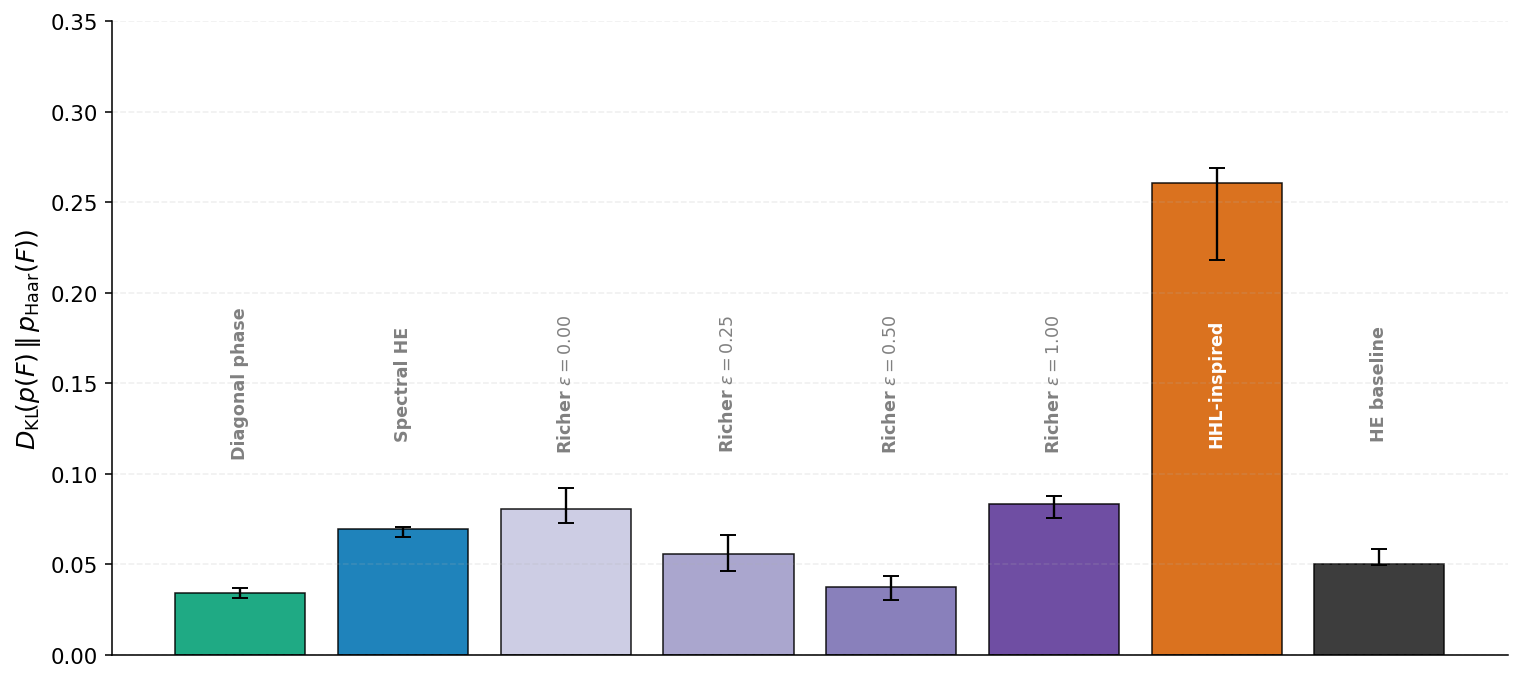

In [18]:
save_figures = True
fig_dir = "paper_figures"
os.makedirs(fig_dir, exist_ok=True)

exclude_models = {"spectral_filter_baseline", "hhl_like_structured"}
plot_model_keys = [mk for mk in all_model_keys if mk not in exclude_models]

label_map = {
    "diag_phase_free": "Diagonal phase",
    "unitary": "Spectral HE",
    "hhl_like_free": "HHL-inspired",
    "hwe": "HE baseline",
}

for eps in richer_epsilon_list:
    label_map[f"richer_spectral_eps_{eps:.2f}"] = rf"Richer $\epsilon={eps:.2f}$"

color_map = {
    "diag_phase_free": "#009E73",
    "unitary": "#0072B2",
    "hhl_like_free": "#D55E00",
    "hwe": "#222222",
}

richer_keys = [
    f"richer_spectral_eps_{eps:.2f}"
    for eps in richer_epsilon_list
    if f"richer_spectral_eps_{eps:.2f}" in plot_model_keys
]

cmap = cm.get_cmap("Purples", len(richer_keys) + 3)
for i, mk in enumerate(richer_keys):
    color_map[mk] = cmap(i + 2)

plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 13,
    "ytick.labelsize": 11,
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "axes.grid": True,
    "grid.alpha": 0.20,
    "grid.linestyle": "--",
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def expressibility_stats(model_key):
    arr = np.array(
        [res[model_key]["expressibility"] for res in all_results],
        dtype=float
    )

    med = np.median(arr)
    q25 = np.percentile(arr, 25)
    q75 = np.percentile(arr, 75)

    return med, q25, q75


# ============================================================
# Collect values
# ============================================================

vals, q25s, q75s, cols = [], [], [], []

for mk in plot_model_keys:
    med, q25, q75 = expressibility_stats(mk)

    vals.append(med)
    q25s.append(q25)
    q75s.append(q75)
    cols.append(color_map.get(mk))

vals = np.array(vals)
q25s = np.array(q25s)
q75s = np.array(q75s)

# ============================================================
# Plot
# ============================================================

x = np.arange(len(plot_model_keys))
ymax = np.ceil(np.max(q75s) * 10) / 10

fig, ax = plt.subplots(figsize=(11, 5.0))

bars = ax.bar(
    x,
    vals,
    color=cols,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.88,
)

# Error bars
yerr = np.vstack([vals - q25s, q75s - vals])

ax.errorbar(
    x,
    vals,
    yerr=yerr,
    fmt="none",
    ecolor="black",
    elinewidth=1.2,
    capsize=4,
)

# ============================================================
# Labels centered at y = 0.15
# ============================================================

label_y = 0.15

for i, bar in enumerate(bars):

    mk = plot_model_keys[i]
    label = label_map.get(mk, mk)

    xloc = bar.get_x() + bar.get_width()/2

    txt_color = "white" if mk == "hhl_like_free" else "gray"

    ax.text(
        xloc,
        label_y,
        label,
        ha="center",
        va="center",
        rotation=90,
        fontsize=9,
        color=txt_color,
        weight="bold",
    )

# remove x ticks
ax.set_xticks([])

# ============================================================
# Y axis
# ============================================================

ax.set_ylim(0, ymax + 0.05)

ax.set_ylabel(
    #r"$D_{\mathrm{KL}}\!\left(p(F)\,\|\,p_{\mathrm{Haar}}(F)\right)$"
    r"$D_{\mathrm{KL}}\!\left(p(F)\,\|\,p_{\mathrm{Haar}}(F)\right)$"

)

fig.tight_layout()

# ============================================================
# Save
# ============================================================

if save_figures:
    fig.savefig(
        os.path.join(fig_dir, "fig_expressibility_centered_labels.pdf"),
        bbox_inches="tight",
    )
    fig.savefig(
        os.path.join(fig_dir, "fig_expressibility_centered_labels.png"),
        bbox_inches="tight",
    )

plt.show()

## Fidelity

/tmp/ipykernel_2479156/2505959691.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Purples", len(richer_keys) + 3)


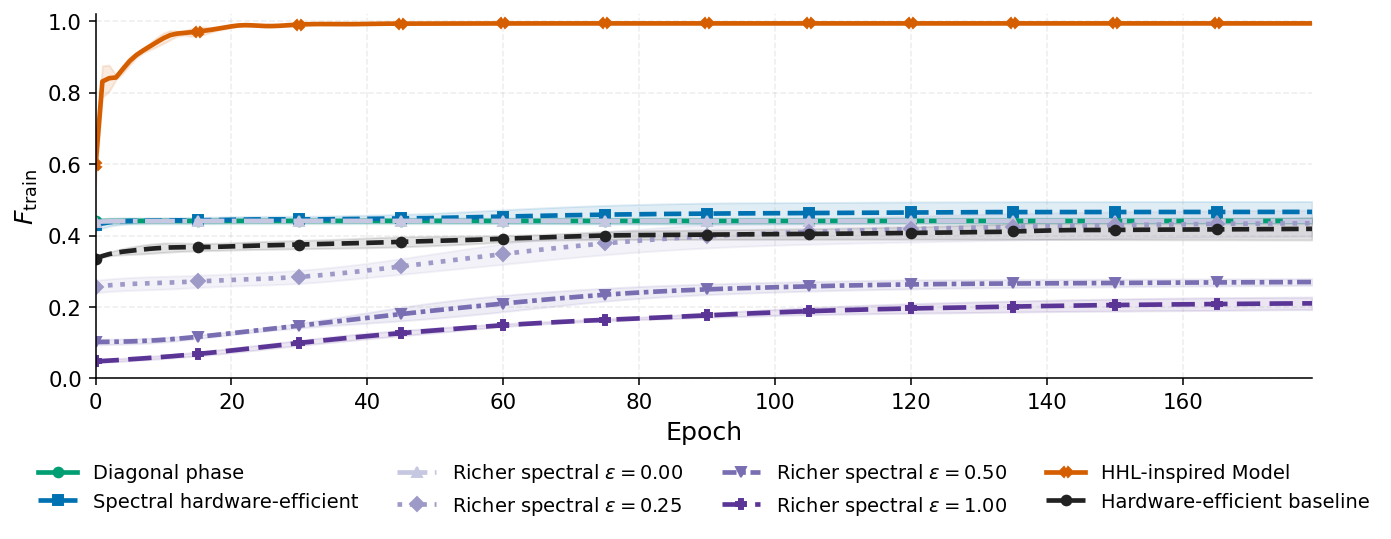

In [19]:
save_figures = True
fig_dir = "paper_figures"
os.makedirs(fig_dir, exist_ok=True)

exclude_models = {"spectral_filter_baseline", "hhl_like_structured"}
plot_model_keys = [mk for mk in all_model_keys if mk not in exclude_models]

label_map = {
    "diag_phase_free": "Diagonal phase",
    "unitary": "Spectral hardware-efficient",
    "hhl_like_free": "HHL-inspired Model",
    "hwe": "Hardware-efficient baseline",
}

for eps in richer_epsilon_list:
    label_map[f"richer_spectral_eps_{eps:.2f}"] = rf"Richer spectral $\epsilon={eps:.2f}$"

color_map = {
    "diag_phase_free": "#009E73",
    "unitary": "#0072B2",
    "hhl_like_free": "#D55E00",
    "hwe": "#222222",
}

richer_keys = [
    f"richer_spectral_eps_{eps:.2f}"
    for eps in richer_epsilon_list
    if f"richer_spectral_eps_{eps:.2f}" in plot_model_keys
]

cmap = cm.get_cmap("Purples", len(richer_keys) + 3)
for i, mk in enumerate(richer_keys):
    color_map[mk] = cmap(i + 2)

line_styles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1)), (0, (5, 2))]
markers = ["o", "s", "^", "D", "v", "P", "X"]

style_map = {
    mk: {
        "linestyle": line_styles[i % len(line_styles)],
        "marker": markers[i % len(markers)],
    }
    for i, mk in enumerate(plot_model_keys)
}

plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "lines.linewidth": 2.4,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "grid.linestyle": "--",
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def train_fidelity_mean_std(model_key):
    arr = np.stack(
        [res[model_key]["train_fid"] for res in all_results],
        axis=0
    )
    mean = np.mean(arr, axis=0)
    std = np.std(arr, axis=0)
    return mean, std


epochs = np.arange(n_epochs)

fig, ax = plt.subplots(figsize=(10.5, 4.8))

for mk in plot_model_keys:
    mean, std = train_fidelity_mean_std(mk)

    ax.plot(
        epochs,
        mean,
        label=label_map.get(mk, mk),
        color=color_map.get(mk),
        linestyle=style_map[mk]["linestyle"],
        marker=style_map[mk]["marker"],
        markersize=5.0,
        markevery=max(1, n_epochs // 12),
    )

    ax.fill_between(
        epochs,
        np.clip(mean - std, 0.0, 1.0),
        np.clip(mean + std, 0.0, 1.0),
        color=color_map.get(mk),
        alpha=0.12,
    )

ax.set_xlim(0, n_epochs - 1)
ax.set_ylim(0.0, 1.02)

ax.set_xlabel("Epoch")
#ax.set_ylabel(r"$F_{\mathrm{train}}=|\langle u_\theta,u\rangle|^2$")
ax.set_ylabel(r"$F_{\mathrm{train}}$")


ax.legend(
    frameon=False,
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
)

fig.tight_layout(rect=[0, 0.13, 1, 1])

if save_figures:
    fig.savefig(
        os.path.join(fig_dir, "fig_training_fidelity_paper.pdf"),
        bbox_inches="tight",
    )
    fig.savefig(
        os.path.join(fig_dir, "fig_training_fidelity_paper.png"),
        bbox_inches="tight",
    )

plt.show()